# EN3160 L03 — Separability, Median Filter, Bilateral Filter
Companion to `gaussian_kernel_practice.ipynb`. Three sections, each demonstrating one concept from your L03 study guide that the kernel-construction notebook didn't cover.

## Setup

In [ ]:
import time
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im = cv.imread("D:\Abdul Rahman\Engineering_UOM\.Sem 5\EN3160 - Image Processing and Computer Vision\EN3160-Image-processing-and-Machine-Vision\images\sigiriya.jpg" , cv.IMREAD_REDUCED_GRAYSCALE_2)
assert im is not None


## 1. Separability — proving the two 1D passes equal one 2D pass, and timing the difference
Study guide section 10: a 2D Gaussian factors into two identical 1D Gaussians. This means you can filter every row, then filter every column of that result, and get the same answer as a full 2D convolution — for a fraction of the compute.

In [4]:
size, sigma = 15, 3.0   # a deliberately largeish kernel so the timing difference is visible

kernel_1d = cv.getGaussianKernel(size, sigma)          # shape (size, 1)
kernel_2d = kernel_1d @ kernel_1d.T                     # outer product -> full 2D kernel

# Full 2D convolution, done directly with filter2D
t0 = time.perf_counter()
result_2d = cv.filter2D(im, cv.CV_32F, kernel_2d)
t_2d = time.perf_counter() - t0

# Separable version: sepFilter2D applies the row kernel then the column kernel internally
t0 = time.perf_counter()
result_sep = cv.sepFilter2D(im, cv.CV_32F, kernel_1d, kernel_1d)
t_sep = time.perf_counter() - t0

print(f"2D filter2D time:   {t_2d*1000:.3f} ms")
print(f"separable time:     {t_sep*1000:.3f} ms")
print(f"max pixel difference between the two results: {np.abs(result_2d - result_sep).max():.6f}")


2D filter2D time:   17.609 ms
separable time:     22.611 ms
max pixel difference between the two results: 0.000092


The pixel difference should be at (or extremely near) zero — the two are mathematically the same operation. The timing gap is the actual point: it should widen further if you increase `size` (try 25 or 31) — that's the `O(n^2 m^2)` vs `O(n^2 m)` gap from your study guide made concrete, rather than just a formula on paper.

### Do it manually with two `filter2D` calls (no `sepFilter2D` shortcut)
Useful to see explicitly that it really is just "filter rows, then filter the result by columns" — two 1D kernels applied one after another.

In [5]:
row_kernel = kernel_1d.reshape(1, -1)   # 1 x size, filters along columns (horizontal)
col_kernel = kernel_1d.reshape(-1, 1)   # size x 1, filters along rows (vertical)

pass1 = cv.filter2D(im, cv.CV_32F, row_kernel)
pass2 = cv.filter2D(pass1, cv.CV_32F, col_kernel)

print("manual two-pass matches full 2D result:",
      np.allclose(pass2, result_2d, atol=1e-3))


manual two-pass matches full 2D result: True


## 2. Median filter — the fix for salt-and-pepper noise that Gaussian can't fix
Study guide section 11. First, manufacture salt-and-pepper noise on the clean image so there's something concrete to compare against (rather than trusting an already-noisy source image).

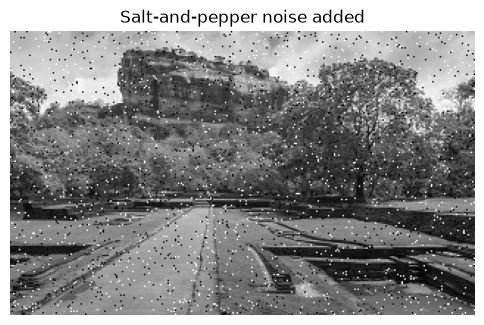

In [6]:
noisy = im.copy()
rng = np.random.default_rng(seed=0)
noise_mask = rng.random(im.shape)

noisy[noise_mask < 0.02] = 0      # 2% of pixels forced to pure black (pepper)
noisy[noise_mask > 0.98] = 255    # 2% of pixels forced to pure white (salt)

plt.figure(figsize=(6, 6))
plt.imshow(noisy, cmap='gray')
plt.title('Salt-and-pepper noise added')
plt.axis('off')
plt.show()


### Compare Gaussian blur vs. median filter on the same noisy image

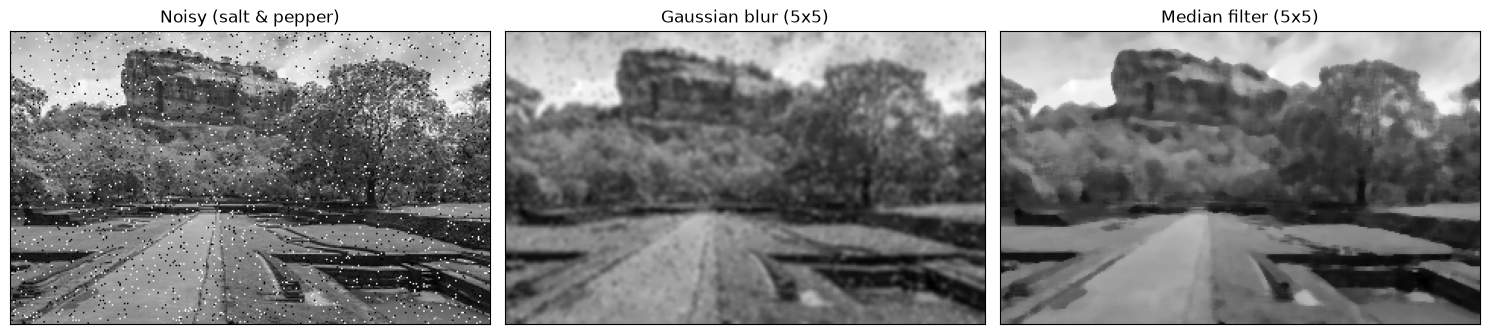

In [7]:
gaussian_cleaned = cv.GaussianBlur(noisy, (5, 5), sigmaX=1.5)
median_cleaned = cv.medianBlur(noisy, 5)   # kernel size 5 -> 5x5 window, takes the middle value

fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharex='all', sharey='all')
ax[0].imshow(noisy, cmap='gray')
ax[0].set_title('Noisy (salt & pepper)')
ax[1].imshow(gaussian_cleaned, cmap='gray')
ax[1].set_title('Gaussian blur (5x5)')
ax[2].imshow(median_cleaned, cmap='gray')
ax[2].set_title('Median filter (5x5)')
for a in ax:
    a.set_xticks([]), a.set_yticks([])
plt.tight_layout()
plt.show()


Look closely at the Gaussian result — the salt/pepper spikes are still visible as faint blurred specks, because averaging just smears an extreme value into its neighbors rather than removing it. The median result should have far fewer visible specks, since sorting and taking the middle value discards outliers entirely, exactly as in the by-hand worked example in your study guide.

### Manual median, by hand, on one small window
Confirms the mechanism directly: sort the window, take the middle value.

In [8]:
window = np.array([[14, 200,   9],
                    [11,   8, 250],
                    [12,  13,  10]])

sorted_values = np.sort(window.flatten())
median_value = sorted_values[len(sorted_values) // 2]

print("window:\n", window)
print("sorted: ", sorted_values)
print("median: ", median_value)


window:
 [[ 14 200   9]
 [ 11   8 250]
 [ 12  13  10]]
sorted:  [  8   9  10  11  12  13  14 200 250]
median:  12


## 3. Bilateral filter — edge-preserving smoothing
Study guide section 12. Combines a spatial Gaussian weight with a range (intensity) Gaussian weight, so smoothing happens within flat regions but not across strong edges.

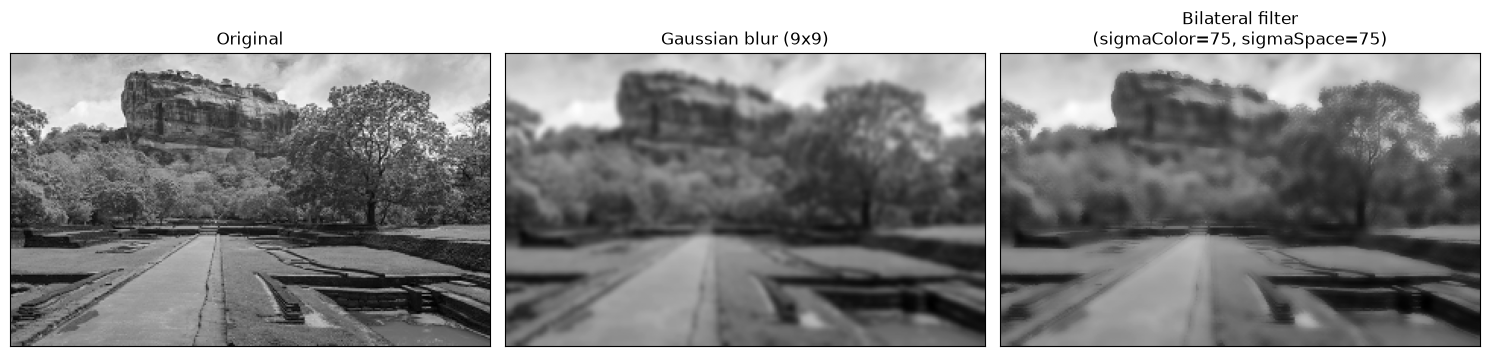

In [9]:
bilateral = cv.bilateralFilter(im, d=9, sigmaColor=75, sigmaSpace=75)
gaussian_plain = cv.GaussianBlur(im, (9, 9), sigmaX=0)

fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharex='all', sharey='all')
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(gaussian_plain, cmap='gray')
ax[1].set_title('Gaussian blur (9x9)')
ax[2].imshow(bilateral, cmap='gray')
ax[2].set_title('Bilateral filter\n(sigmaColor=75, sigmaSpace=75)')
for a in ax:
    a.set_xticks([]), a.set_yticks([])
plt.tight_layout()
plt.show()


The Gaussian result should look uniformly softened everywhere, including along strong edges (rock outline, tree silhouettes). The bilateral result should keep those edges noticeably sharper while still smoothing flatter regions like the sky.

### See `sigmaColor` degenerate the bilateral filter toward a plain Gaussian
Study guide's claim: if `sigmaColor` (the range/intensity sigma) is very large, the range weight becomes nearly constant everywhere, so bilateral collapses to an ordinary Gaussian blur. Confirm this yourself.

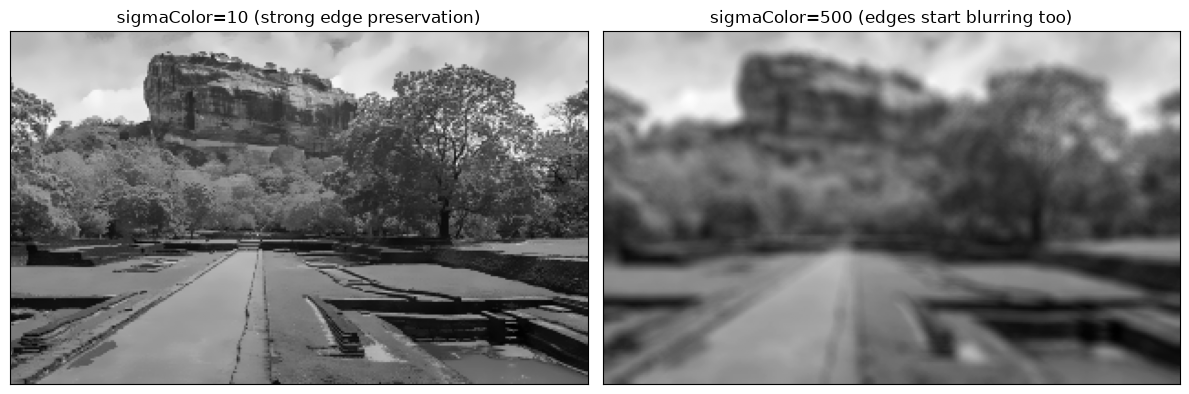

max difference between large-sigmaColor bilateral and plain Gaussian: 21.0


In [10]:
bilateral_small_sigma_color = cv.bilateralFilter(im, d=9, sigmaColor=10, sigmaSpace=75)
bilateral_large_sigma_color = cv.bilateralFilter(im, d=9, sigmaColor=500, sigmaSpace=75)

fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex='all', sharey='all')
ax[0].imshow(bilateral_small_sigma_color, cmap='gray')
ax[0].set_title('sigmaColor=10 (strong edge preservation)')
ax[1].imshow(bilateral_large_sigma_color, cmap='gray')
ax[1].set_title('sigmaColor=500 (edges start blurring too)')
for a in ax:
    a.set_xticks([]), a.set_yticks([])
plt.tight_layout()
plt.show()

print("max difference between large-sigmaColor bilateral and plain Gaussian:",
      np.abs(bilateral_large_sigma_color.astype(float) - gaussian_plain.astype(float)).max())
